# Лабораторна робота № 2. Лічильник на PostgreSQL: способи оновлення і втрата значень

Вовкотруб Олександр Віталійович, група ФБ-61мн.
КПІ ім. Ігоря Сікорського, ННФТІ, кафедра інформаційної безпеки.
Дисципліна «Проєктування високонавантажених систем», викладач Родіонов А. М.

Ноутбук аналізує вже зняті вимірювання: усі числа беруться з
`reports/data/*.csv`, медіани й діапазони рахуються тут же в pandas, а
рисунки зберігаються в `assets/` у тому порядку, у якому стоять у звіті.
Наприкінці розділ «Жива перевірка» запускає справжні Swift-програми на
зменшеному навантаженні.

## 0. Підготовка середовища

Корінь репозиторію шукаємо від поточної теки вгору до `Package.swift`, тож
ноутбук працює і зі своєї теки, і з кореня. Прапорець `RUN_LIVE`
вмикає розділ із живими запусками: без нього ноутбук лише читає CSV.

In [1]:
import os
import re
import shutil
import subprocess
import tempfile
from io import StringIO
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, MultipleLocator

RUN_LIVE = True


def find_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "Package.swift").is_file():
            return d
    raise FileNotFoundError("не знайдено Package.swift вище за " + str(start))


ROOT = find_root(Path.cwd().resolve())
# Тека ноутбука: поточна, якщо ноутбук запущено з неї, інакше його
# місце в репозиторії.
LAB = Path.cwd() if (Path.cwd() / "solution.ipynb").is_file() else next(
    p for p in (ROOT / "lab2", ROOT / "Labs" / "02-postgresql") if p.is_dir())
DATA = ROOT / "reports" / "data"
ASSETS = LAB / "assets"
ASSETS.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Liberation Serif", "DejaVu Serif"],
    "font.monospace": ["Liberation Mono", "DejaVu Sans Mono"],
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "x",
    "grid.color": "#D7DAE3",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
})
pd.set_option("display.width", 140)

# Ті самі кольори, що в презентації (slides/deck_theme.py). Варіант має
# один колір на всіх рисунках: сірий, якщо він втрачає інкременти, синій,
# якщо результат точний. Сховища: пам'ять зелена, файл помаранчевий,
# PostgreSQL синій, як in-place, яким він і користується.
EXACT, LOSES = "#0E6BA8", "#9CA3AF"
INK = "#1A233B"
STORE_COLORS = {"memory": "#1B8A5E", "disk": "#B45309", "postgres": "#0E6BA8"}
STORE_NAMES = {"memory": "In-memory", "disk": "Disk", "postgres": "PostgreSQL"}
VARIANTS = ["lost-update", "serializable", "serializable-retry",
            "in-place", "for-update", "optimistic"]
LOSING = {"lost-update", "serializable"}
VARIANT_COLORS = {v: LOSES if v in LOSING else EXACT for v in VARIANTS}


def uk(x: float, digits: int = 1) -> str:
    """Число в українському записі: кома й нерозривний пробіл між тисячами."""
    s = f"{x:,.{digits}f}"
    return s.replace(",", "\u00a0").replace(".", ",")


def save(fig, name: str) -> Path:
    path = ASSETS / name
    fig.savefig(path, dpi=200, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    display(Image(filename=str(path), width=760))
    return path


def show_swift(rel: str, start: str, end: str) -> None:
    """Надрукувати фрагмент Swift-файла від рядка з `start` до рядка з `end`
    включно, з номерами рядків. Фрагмент знаходиться за текстом, тому
    номери завжди відповідають поточному коду."""
    lines = (ROOT / rel).read_text(encoding="utf-8").splitlines()
    i = next(k for k, ln in enumerate(lines) if start in ln)
    j = next(k for k in range(i, len(lines)) if end in lines[k])
    print(f"{rel}, рядки {i + 1}...{j + 1}")
    for k in range(i, j + 1):
        print(f"{k + 1:4d}  {lines[k]}")


print("корінь репозиторію:", ROOT.name)
print("дані:", sorted(p.name for p in DATA.glob("*.csv")))

корінь репозиторію: HighLoadSystems
дані: ['1brc-steps.csv', 'task1-flamegraph-runs.csv', 'task1-fsync-probe.csv', 'task1.csv', 'task2-bench.csv', 'task2-wal-probe.csv', 'task2-web.csv', 'task3-bench.csv', 'task3-web.csv', 'throughput-ab.csv']


## 1. Постановка

Лічильник зберігається в таблиці `user_counter (user_id, counter, version)`,
один рядок на користувача. Частина I: 10 з'єднань одночасно роблять по
10 000 інкрементів (разом 100 000) кожним із шести способів, кожен інкремент
в окремій транзакції. Частина II: PostgreSQL з in-place `UPDATE` стає
сховищем веб-лічильника з лабораторної роботи № 1 і порівнюється зі
сховищем у пам'яті та у файлі.

Кожен вимір повторено тричі. Скрипт `scripts/task2.sh` пише рядок на запуск
у `task2-bench.csv` і `task2-web.csv`, `scripts/pg-wal-probe.sh` пише
`task2-wal-probe.csv`, дані для пам'яті й файла взято з `task1.csv`.

In [2]:
bench = pd.read_csv(DATA / "task2-bench.csv")
probe = pd.read_csv(DATA / "task2-wal-probe.csv")
web_pg = pd.read_csv(DATA / "task2-web.csv")
task1 = pd.read_csv(DATA / "task1.csv")
print(f"task2-bench.csv: {len(bench)} рядків, повтори {sorted(int(r) for r in bench['repeat'].unique())}")
print(f"task2-wal-probe.csv: {len(probe)} рядків")
print(f"task2-web.csv: {len(web_pg)} рядків, task1.csv: {len(task1)} рядків")
bench.head(6)

task2-bench.csv: 18 рядків, повтори [1, 2, 3]
task2-wal-probe.csv: 6 рядків
task2-web.csv: 3 рядків, task1.csv: 24 рядків


,repeat,variant,workers,increments_per_worker,seconds,ops_per_sec,final_value,expected,lost,errors,retries
0,1,lost-update,10,10000,166.0389,602.3,10000,100000,90000,0,0
1,1,serializable,10,10000,21.2357,4709.0,10002,100000,89998,89998,0
2,1,serializable-retry,10,10000,287.0980,348.3,100000,100000,0,0,879105
3,1,in-place,10,10000,307.6854,325.0,100000,100000,0,0,0
4,1,for-update,10,10000,331.5695,301.6,100000,100000,0,0,0
5,1,optimistic,10,10000,1784.3218,56.0,100000,100000,0,0,488679


## 2. Частина I: шість способів інкременту

Програма `pg-bench` відкриває 10 з'єднань до старту годинника, скидає рядок
до `(1, 0, 0)` і запускає 10 задач у `withThrowingTaskGroup`. Міряється лише
фаза інкрементів.

In [3]:
show_swift("Sources/pg-bench/Bench.swift", "let clock = ContinuousClock()",
           "let elapsed = start.duration")

Sources/pg-bench/Bench.swift, рядки 58...72
  58          let clock = ContinuousClock()
  59          let start = clock.now
  60          let tally = try await withThrowingTaskGroup(of: Tally.self) { group in
  61              for connection in connections {
  62                  group.addTask {
  63                      var tally = Tally()
  64                      for _ in 0..<increments {
  65                          tally.record(try await variant.increment(on: connection, logger: logger))
  66                      }
  67                      return tally
  68                  }
  69              }
  70              return try await group.reduce(into: Tally()) { $0.add($1) }
  71          }
  72          let elapsed = start.duration(to: clock.now)


Самі способи інкременту описано в `Variant.swift`. Lost update читає значення
і пише в рядок `counter + 1`, обчислене в клієнті; in-place доручає додавання
серверу; optimistic оновлює рядок лише за незмінної `version` і починає
спочатку, якщо не оновлено жодного рядка.

In [4]:
show_swift("Sources/pg-bench/Variant.swift", "case .lostUpdate:", "return .done")
print()
show_swift("Sources/pg-bench/Variant.swift", "case .inPlace:", "return .done")
print()
show_swift("Sources/pg-bench/Variant.swift", "case .optimistic:", "retries += 1")

Sources/pg-bench/Variant.swift, рядки 39...44
  39          case .lostUpdate:
  40              try await connection.transaction(logger: logger) { connection in
  41                  let counter = try await connection.single(Int32.self, "SELECT counter FROM user_counter WHERE user_id = 1", logger: logger)
  42                  try await connection.query("UPDATE user_counter SET counter = \(counter + 1) WHERE user_id = 1", logger: logger)
  43              }
  44              return .done

Sources/pg-bench/Variant.swift, рядки 65...69
  65          case .inPlace:
  66              try await connection.transaction(logger: logger) { connection in
  67                  try await connection.query("UPDATE user_counter SET counter = counter + 1 WHERE user_id = 1", logger: logger)
  68              }
  69              return .done

Sources/pg-bench/Variant.swift, рядки 79...100
  79          case .optimistic:
  80              var retries = 0
  81              while true {
  82                

Варіант `serializable-retry` повторює всю транзакцію від `BEGIN`, доки вона
не закомітиться без помилки `40001`:

In [5]:
show_swift("Sources/pg-bench/Variant.swift", "case .serializableRetry:", "retries += 1")

Sources/pg-bench/Variant.swift, рядки 54...61
  54          case .serializableRetry:
  55              var retries = 0
  56              while true {
  57                  do {
  58                      try await serializableReadModifyWrite(on: connection, logger: logger)
  59                      return .done(retries: retries)
  60                  } catch where error.isSerializationFailure {
  61                      retries += 1


### Час: медіана, мінімум і максимум трьох повторів

Таблиця нижче відтворює таблицю 4.1 звіту. Темп `ops_per_sec` дорівнює
100 000 спробам, поділеним на час; для `serializable` успішних серед них
лише близько 10 000.

In [6]:
time_tbl = (bench.groupby("variant")
            .agg(median_s=("seconds", "median"), min_s=("seconds", "min"),
                 max_s=("seconds", "max"), median_ops=("ops_per_sec", "median"))
            .reindex(VARIANTS))
display(time_tbl.round(2))

assert time_tbl.loc["in-place", "median_s"].round(2) == 297.92
assert time_tbl.loc["optimistic", "median_s"].round(2) == 1997.30
assert time_tbl.loc["in-place", "median_ops"] == 335.7

,median_s,min_s,max_s,median_ops
variant,,,,
lost-update,300.01,166.04,319.15,333.3
serializable,34.55,21.24,38.57,2894.3
serializable-retry,344.99,287.10,498.35,289.9
in-place,297.92,173.63,307.69,335.7
for-update,324.26,264.01,331.57,308.4
optimistic,1997.30,1784.32,2565.29,50.1


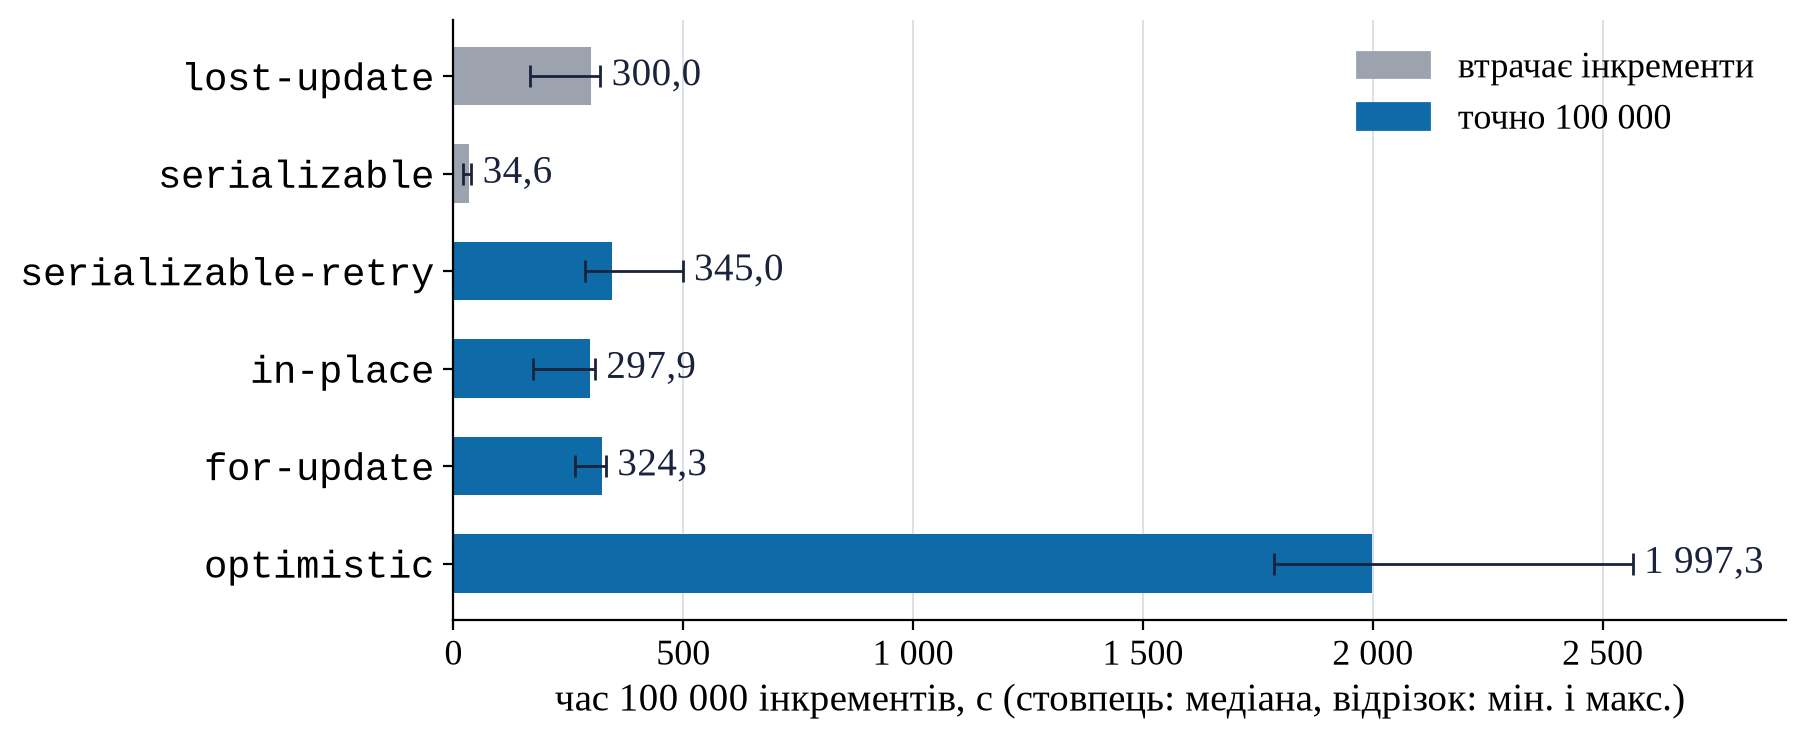

In [7]:
fig, ax = plt.subplots(figsize=(8.6, 3.9))
y = range(len(VARIANTS))[::-1]
for yi, v in zip(y, VARIANTS):
    row = time_tbl.loc[v]
    ax.barh(yi, row.median_s, height=0.6, color=VARIANT_COLORS[v])
    ax.errorbar(row.median_s, yi, xerr=[[row.median_s - row.min_s], [row.max_s - row.median_s]],
                fmt="none", ecolor=INK, elinewidth=1, capsize=4)
    ax.text(row.max_s + 25, yi, uk(row.median_s), va="center", color=INK)
ax.set_yticks(list(y), VARIANTS, family="monospace")
ax.set_xlabel("час 100 000 інкрементів, с (стовпець: медіана, відрізок: мін. і макс.)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: uk(x, 0)))
ax.set_xlim(0, 2900)
ax.legend(handles=[Patch(color=LOSES, label="втрачає інкременти"),
                   Patch(color=EXACT, label="точно 100 000")],
          loc="upper right", frameon=False)
_ = save(fig, "01-variants-time.png")

Чотири варіанти з одним записуючим комітом на інкремент (`lost-update`,
`serializable-retry`, `in-place`, `for-update`) займають від 297,92 до
344,99 с, тобто близько 3 мс на транзакцію. `serializable` найшвидший
(34,55 с) лише тому, що 9 з 10 транзакцій відкочуються. `optimistic`
точний, але в 6,7 раза повільніший за `in-place`.

### Коректність

Таблиця 4.2 звіту: фінальне значення, помилки `40001` і повтори на
інкремент (сума повторів запуску, поділена на 100 000).

In [8]:
bench["retries_per_inc"] = bench["retries"] / bench["expected"]
corr_tbl = (bench.groupby("variant")
            .agg(final_min=("final_value", "min"), final_max=("final_value", "max"),
                 errors_min=("errors", "min"), errors_max=("errors", "max"),
                 retries_min=("retries_per_inc", "min"),
                 retries_med=("retries_per_inc", "median"),
                 retries_max=("retries_per_inc", "max"))
            .reindex(VARIANTS))
display(corr_tbl.round(2))

# SERIALIZABLE не втрачає закомічене: фінальне значення дорівнює кількості
# успішних транзакцій у кожному запуску.
ser = bench[bench["variant"] == "serializable"]
assert (ser["final_value"] == ser["expected"] - ser["errors"]).all()
exact = bench[~bench["variant"].isin(LOSING)]
assert (exact["final_value"] == 100_000).all()
print("serializable, фінальне значення = 100 000 - помилки:",
      list(zip(ser["final_value"], ser["errors"])))

,final_min,final_max,errors_min,errors_max,retries_min,retries_med,retries_max
variant,,,,,,,
lost-update,10000,10044,0,0,0.00,0.00,0.00
serializable,10000,10003,89997,90000,0.00,0.00,0.00
serializable-retry,100000,100000,0,0,8.59,8.69,8.79
in-place,100000,100000,0,0,0.00,0.00,0.00
for-update,100000,100000,0,0,0.00,0.00,0.00
optimistic,100000,100000,0,0,4.89,5.50,7.20


serializable, фінальне значення = 100 000 - помилки: [(10002, 89998), (10000, 90000), (10003, 89997)]


`lost-update` закінчує на 10 000...10 044 зі 100 000 без жодної помилки:
втрачено близько 90 % інкрементів. `serializable` теж дає близько 10 000,
але кожен втрачений інкремент тут видимий як помилка `40001`, а фінальне
значення точно дорівнює числу успішних транзакцій. Усі чотири інші варіанти
дають рівно 100 000 у кожному з трьох повторів.

## 3. Проба WAL: fsync і повтори на інкремент

Скрипт `scripts/pg-wal-probe.sh` проганяє кожен варіант ще раз у масштабі
10 × 1 000 і знімає дельти `xact_commit`, `xact_rollback` з
`pg_stat_database` та `fsyncs` журналу WAL з `pg_stat_io`. Таблиця 4.3 звіту:

In [9]:
probe_tbl = probe.set_index("variant").reindex(VARIANTS)[
    ["seconds", "final_value", "commits", "rollbacks", "wal_fsyncs", "wal_fsyncs_per_increment"]]
display(probe_tbl)
assert probe_tbl.loc["in-place", "wal_fsyncs_per_increment"] == 1.000
assert probe_tbl.loc["optimistic", "wal_fsyncs_per_increment"] == 5.988

,seconds,final_value,commits,rollbacks,wal_fsyncs,wal_fsyncs_per_increment
variant,,,,,,
lost-update,26.9062,1000,10014,0,10003,1.000
serializable,2.7315,1008,1022,8992,1017,0.102
serializable-retry,26.2456,10000,10019,83866,10052,1.005
in-place,16.8553,10000,10014,0,10001,1.000
for-update,19.5327,10000,10014,0,10001,1.000
optimistic,186.9836,10000,59904,0,59884,5.988


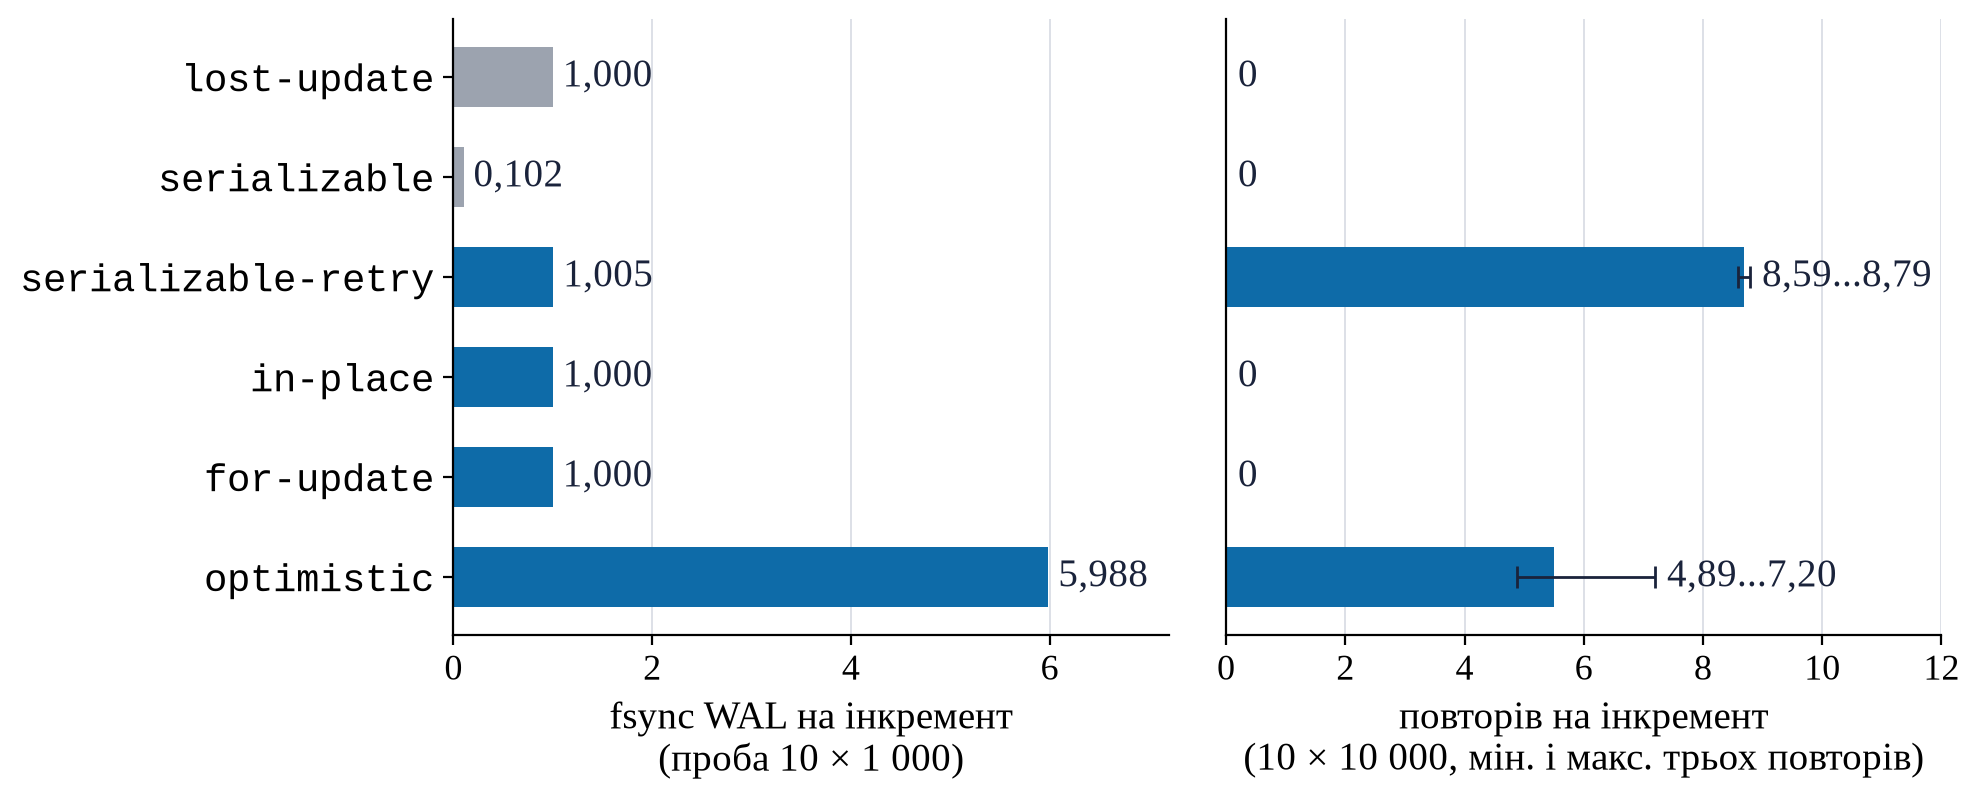

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 4.0), sharey=True,
                               gridspec_kw={"wspace": 0.08})
y = list(range(len(VARIANTS)))[::-1]
for yi, v in zip(y, VARIANTS):
    f = probe_tbl.loc[v, "wal_fsyncs_per_increment"]
    ax1.barh(yi, f, height=0.6, color=VARIANT_COLORS[v])
    ax1.text(f + 0.1, yi, uk(f, 3), va="center", color=INK)
    r = corr_tbl.loc[v]
    ax2.barh(yi, r.retries_med, height=0.6, color=VARIANT_COLORS[v])
    if r.retries_max > 0:
        ax2.errorbar(r.retries_med, yi,
                     xerr=[[r.retries_med - r.retries_min], [r.retries_max - r.retries_med]],
                     fmt="none", ecolor=INK, elinewidth=1, capsize=4)
        label = f"{uk(r.retries_min, 2)}...{uk(r.retries_max, 2)}"
    else:
        label = "0"
    ax2.text(r.retries_max + 0.2, yi, label, va="center", color=INK)
ax1.set_yticks(y, VARIANTS, family="monospace")
ax1.set_xlim(0, 7.2)
ax2.set_xlim(0, 12)
ax2.xaxis.set_major_locator(MultipleLocator(2))
ax1.set_xlabel("fsync WAL на інкремент\n(проба 10 × 1 000)")
ax2.set_xlabel("повторів на інкремент\n(10 × 10 000, мін. і макс. трьох повторів)")
for ax in (ax1, ax2):
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: uk(x, 0)))
ax2.tick_params(axis="y", length=0)
_ = save(fig, "02-wal-fsync-retries.png")

Ліва панель пояснює час з рисунка 1: кожен записуючий `COMMIT` чекає
`fdatasync` WAL, тому варіанти з одним комітом на інкремент мають рівно
1,000 `fsync`. Повтори `serializable-retry` (8,59...8,79 на інкремент)
закінчуються `ROLLBACK` і диска не чекають: 1,005 `fsync`. Невдала спроба
`optimistic` (4,89...7,20 повтору) закінчується `COMMIT`, тому вона коштує
близько 6 `fsync` на інкремент, і це прямо дає 6,7-кратне сповільнення.

## 4. Частина II: сховище веб-лічильника

`PostgresCounterStore` тримає пул до 20 з'єднань і на кожен `GET /inc`
виконує один in-place `UPDATE` в autocommit-транзакції:

In [11]:
show_swift("Sources/CounterCore/PostgresCounterStore.swift",
           "public func increment()", "    }")

Sources/CounterCore/PostgresCounterStore.swift, рядки 47...49
  47      public func increment() async throws {
  48          try await client.query("UPDATE user_counter SET counter = counter + 1 WHERE user_id = \(Self.userID)")
  49      }


Навантаження: 10 клієнтів `loadgen` по 10 000 запитів, три повтори. Рядки
для пам'яті й файла беремо з `task1.csv` при 10 клієнтах. Таблиця 4.4 звіту:

In [12]:
web = pd.concat([task1[task1["clients"] == 10], web_pg], ignore_index=True)
store_tbl = (web.groupby("store")
             .agg(median_s=("seconds", "median"), median_rps=("rps", "median"),
                  min_rps=("rps", "min"), max_rps=("rps", "max"),
                  correct=("correct", "sum"), runs=("correct", "size"))
             .reindex(["memory", "disk", "postgres"]))
display(store_tbl.round(2))

pg_rps = store_tbl.loc["postgres", "median_rps"]
print(f"PostgreSQL / файл: {uk(pg_rps / store_tbl.loc['disk', 'median_rps'], 2)}")
print(f"пам'ять / PostgreSQL: {uk(store_tbl.loc['memory', 'median_rps'] / pg_rps)}")
print(f"pg-bench in-place, інкр./с: {time_tbl.loc['in-place', 'median_ops']}")
assert (store_tbl["correct"] == store_tbl["runs"]).all()
assert pg_rps == 330.6

,median_s,median_rps,min_rps,max_rps,correct,runs
store,,,,,,
memory,3.20,31256.0,30215.1,34299.7,3,3
disk,818.08,122.2,121.3,122.8,3,3
postgres,302.44,330.6,326.6,500.6,3,3


PostgreSQL / файл: 2,71
пам'ять / PostgreSQL: 94,5
pg-bench in-place, інкр./с: 335.7


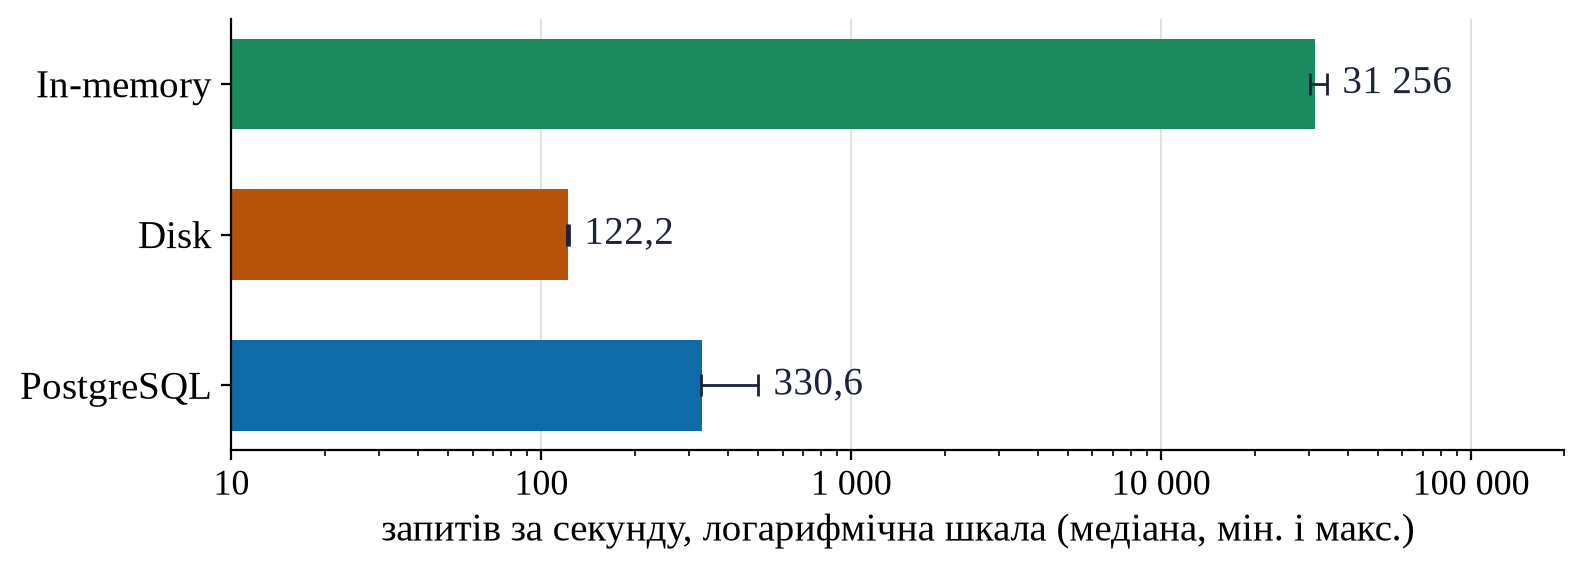

In [13]:
stores = ["memory", "disk", "postgres"]
fig, ax = plt.subplots(figsize=(8.6, 2.8))
y = list(range(len(stores)))[::-1]
for yi, st in zip(y, stores):
    r = store_tbl.loc[st]
    ax.barh(yi, r.median_rps, height=0.6, color=STORE_COLORS[st])
    ax.errorbar(r.median_rps, yi, xerr=[[r.median_rps - r.min_rps], [r.max_rps - r.median_rps]],
                fmt="none", ecolor=INK, elinewidth=1, capsize=4)
    digits = 0 if r.median_rps >= 1000 else 1
    ax.text(r.max_rps * 1.12, yi, uk(r.median_rps, digits), va="center", color=INK)
ax.set_xscale("log")
ax.set_xlim(10, 200_000)
ax.set_yticks(y, [STORE_NAMES[s] for s in stores])
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: uk(x, 0)))
ax.set_xlabel("запитів за секунду, логарифмічна шкала (медіана, мін. і макс.)")
_ = save(fig, "03-storage-rps.png")

Веб-лічильник на PostgreSQL дає 330,6 RPS, майже стільки ж, скільки
`pg-bench in-place` (335,7 інкр./с): HTTP і пул на фоні 3 мс коміту
непомітні. Це у 2,7 раза більше, ніж файл з повним `fsync` (122,2 RPS), і
приблизно в 95 разів менше, ніж пам'ять (31 256 RPS). Логарифмічна шкала
потрібна, бо пам'ять на два порядки швидша за обидва довговічні сховища.

## 5. Жива перевірка

**Демонстрація на зменшеному навантаженні.** Офіційні числа звіту взято з
CSV вище; тут лише показано, що ті самі програми й зараз поводяться так
само. Клітинка запускає локальний кластер `scripts/pg.sh start` (порт 21410),
проганяє `pg-bench` для `lost-update`, `in-place` і `optimistic` з 10
з'єднаннями по 200 інкрементів (2 000 очікуваних) і в блоці `finally`
зупиняє кластер, якщо його запустила саме вона. Журнали серверів ідуть у
тимчасову теку (`HLS_LOG_DIR`), тож `reports/logs` не перезаписується.
Якщо release-збірки `pg-bench` немає, клітинка спершу її збирає.

In [14]:
def sh(cmd: str, timeout: float, env: dict) -> subprocess.CompletedProcess:
    """Виконати команду з кореня репозиторію в оточенні scripts/env.sh.
    Без swift або pg_ctl у PATH команда йде через `direnv exec`."""
    full = ["bash", "-c", f"source scripts/env.sh >/dev/null && {cmd}"]
    if shutil.which("swift") is None or shutil.which("pg_ctl") is None:
        full = ["direnv", "exec", str(ROOT), *full]
    return subprocess.run(full, cwd=ROOT, env=env, capture_output=True, text=True,
                          timeout=timeout)


live = None
if RUN_LIVE:
    log_dir = Path(tempfile.mkdtemp(prefix="hls-lab02-logs-"))
    env = {**os.environ, "HLS_LOG_DIR": str(log_dir)}
    if not (ROOT / ".build/release/pg-bench").exists():
        print("збираю pg-bench (release)...")
        sh("hls_build_release --product pg-bench", timeout=900, env=env).check_returncode()

    was_running = sh("scripts/pg.sh status", timeout=30, env=env).returncode == 0
    rows = []
    try:
        if not was_running:
            r = sh("scripts/pg.sh start", timeout=60, env=env)
            first = r.stderr.strip().splitlines()[0] if r.stderr.strip() else "postgres запущено"
            print(first.replace(str(ROOT) + "/", ""))
            r.check_returncode()
        for v in ["lost-update", "in-place", "optimistic"]:
            r = sh(f'"$HLS_BIN/pg-bench" --variant {v} --workers 10 --increments 200 '
                   f'--pg-url "$PG_URL" --header', timeout=60, env=env)
            if r.returncode != 0:
                raise RuntimeError(f"pg-bench {v}: код {r.returncode}\n{r.stderr}")
            rows.append(pd.read_csv(StringIO(r.stdout)))
    finally:
        if not was_running:
            print(sh("scripts/pg.sh stop", timeout=60, env=env).stderr.strip())
        shutil.rmtree(log_dir, ignore_errors=True)
    live = pd.concat(rows, ignore_index=True)
    display(live[["variant", "workers", "increments_per_worker", "seconds",
                  "final_value", "expected", "lost", "retries"]])
else:
    print("RUN_LIVE = False: живі запуски пропущено")

postgres started on 127.0.0.1:21410 (log: .pgdata/server.log)


postgres stopped


,variant,workers,increments_per_worker,seconds,final_value,expected,lost,retries
0,lost-update,10,200,3.2686,200,2000,1800,0
1,in-place,10,200,3.3514,2000,2000,0,0
2,optimistic,10,200,18.3877,2000,2000,0,9000


In [15]:
if live is not None:
    by = live.set_index("variant")
    assert by.loc["in-place", "final_value"] == by.loc["in-place", "expected"]
    assert by.loc["optimistic", "final_value"] == by.loc["optimistic", "expected"]
    def n(v: str, col: str) -> int:
        return int(by.loc[v, col])

    print(f"lost-update: {n('lost-update', 'final_value')} з {n('lost-update', 'expected')}, "
          f"втрачено {n('lost-update', 'lost')} "
          f"({n('lost-update', 'lost') / n('lost-update', 'expected'):.0%}) без жодної помилки")
    print(f"in-place: {n('in-place', 'final_value')} з {n('in-place', 'expected')}")
    print(f"optimistic: {n('optimistic', 'final_value')} з {n('optimistic', 'expected')}, "
          f"{uk(n('optimistic', 'retries') / n('optimistic', 'expected'), 2)} повтору на інкремент, "
          f"у {uk(by.loc['optimistic', 'seconds'] / by.loc['in-place', 'seconds'])} раза довше "
          f"за in-place")

lost-update: 200 з 2000, втрачено 1800 (90%) без жодної помилки
in-place: 2000 з 2000
optimistic: 2000 з 2000, 4,50 повтору на інкремент, у 5,5 раза довше за in-place


Навіть на 2 000 інкрементів картина та сама, що й на 100 000:
`lost-update` мовчки втрачає більшість інкрементів, `in-place` і
`optimistic` дають точне значення, а `optimistic` платить за це повторами
і кількаразово довшим часом. Абсолютний час тут не порівнюється з
таблицями вище: прогін короткий і припадає на інший режим затримки диска.

## Висновки

1. Read-modify-write під READ COMMITTED (`lost-update`) втрачає близько
   90 % інкрементів: фінальне значення 10 000...10 044 зі 100 000, без
   жодної помилки.
2. SERIALIZABLE не втрачає закомічене: фінальне значення дорівнює числу
   успішних транзакцій, але 89 997...90 000 транзакцій падають з `40001`.
   Повтор усієї транзакції від `BEGIN` дає рівно 100 000 за 344,99 с, на
   16 % довше за `in-place`.
3. Найшвидший точний спосіб це `UPDATE ... SET counter = counter + 1`:
   297,92 с, 335,7 інкр./с. `optimistic` на одному гарячому рядку робить
   близько 6 `fsync` на інкремент і займає 1 997,30 с.
4. Час усіх варіантів визначає кількість записуючих комітів: кожен чекає
   `fdatasync` WAL, близько 3 мс.
5. Як сховище веб-лічильника PostgreSQL дає 330,6 RPS: у 2,7 раза більше
   за файл з `fsync` і приблизно в 95 разів менше за пам'ять, з усіма
   100 000 інкрементів у кожному запуску.